In [64]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.optimize import minimize

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'JNJ']
start_date = '2022-01-01'
end_date = '2024-12-31'  

data = yf.download(tickers, start=start_date, end=end_date)['Close']
print("Original Data Shape:", data.shape)
print(data.shape)

# dealing with NaN
# TODO: tackle the problem data more correctly 
data = data.ffill().bfill()

# counting daily return
returns = data.pct_change().dropna()
print("\nReturn Shape:", returns.shape)
print(returns.shape)


[*********************100%***********************]  8 of 8 completed

Original Data Shape: (752, 8)
(752, 8)

Return Shape: (751, 8)
(751, 8)


In [ ]:
def run_strategy(returns):
    bh_ret = buy_and_hold(returns)
    eq_ret = equal_weight_strategy(returns, rebalance_freq=20)
    mv_ret, weights_hist = mean_variance_backtest(returns, lookback=60, rebalance_freq=20)

    return {
        'Buy & Hold': calculate_performance(bh_ret),
        'Equal Weight': calculate_performance(eq_ret),
        'Mean-Variance': calculate_performance(mv_ret),
    }

In [66]:
def calculate_performance(portfolio_returns, risk_free_rate=0.02):
    """
    Input: daily return, assuming the risk free rate is 0.02 ***
    Output: annual volume, annual return, sharpe, maximum drawdown
    """
    # annual return and annual volume
    # assuming that there are 252 trading days in a year ***
    # TODO: make the risk_free_rate keep track of the 3-Month T-Bill Rate
    # TODO: change the number of trading days to the accurate number
    ann_return = portfolio_returns.mean() * 252
    ann_vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol != 0 else 0
    
    cumulative = (1 + portfolio_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    
    return {
        'Annual Return': round(ann_return, 4),
        'Annual Volatility': round(ann_vol, 4),
        'Sharpe': round(sharpe, 4),
        'Maximum Drawdown': round(max_dd, 4)
    }

In [67]:
def calculate_drawdown(returns):
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd

In [68]:
def equal_weight_strategy(returns, rebalance_freq=20):
    """
    Strategy: assign the same portfolio weight to each asset and 
    periodically rebalance to maintain equal allocation
    Input: daily return, rebalance frequency
    Output: series of portfolio daily returns
    TODO: considering transaction fee
    """
    n_assets = returns.shape[1]
    weights = np.array([1/n_assets] * n_assets)
    
    portfolio_returns = []
    dates = returns.index

    for i in range(len(returns)):
        daily_ret = np.dot(weights, returns.iloc[i].values)
        portfolio_returns.append(daily_ret)
        weights = weights * (1 + returns.iloc[1].values)
        weights = weights / weights.sum()
        if (i + 1) % rebalance_freq == 0:
            weights = np.array([1/n_assets] * n_assets)
    
    return pd.Series(portfolio_returns, index=dates)

def buy_and_hold(returns):
    n_assets = returns.shape[1]
    weights = np.array([1/n_assets] * n_assets)
    portfolio_returns = returns.dot(weights)
    return portfolio_returns

def mean_variance_optimization(returns_window, risk_free_rate=0.02):
    """
    Input: historical returns, fixed risk free rate
    Output: the portfolio with the lowest negative sharpe ratio
    """
    n = returns_window.shape[1]
    mean_returns = returns_window.mean() * 252          
    cov_matrix = returns_window.cov() * 252            
    
    def negative_sharpe(weights):
        port_return = np.dot(weights, mean_returns)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(port_return - risk_free_rate) / port_vol
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = np.array([1/n] * n)
    
    result = minimize(negative_sharpe, init_guess, 
                      method='SLSQP', bounds=bounds, constraints=constraints)
    
    return result.x if result.success else init_guess

In [69]:
def mean_variance_backtest(returns, lookback=60, rebalance_freq=20):
    """
    Input: daily return, lookback: the number of trading days that are used to optimize weight, re-optimization frequency
    Output: portfolio returns, weights history
    TODO: considering weight drift
    """
    n_assets = returns.shape[1]
    portfolio_returns = []
    weights_history = []
    current_weights = np.array([1/n_assets] * n_assets)
    
    for i in range(len(returns)):
        if i < lookback:
            daily_ret = np.dot(current_weights, returns.iloc[i].values)
            current_weights = current_weights * (1 + returns.iloc[1].values)
            current_weights = current_weights / current_weights.sum()
            portfolio_returns.append(daily_ret)
            continue
        
        if (i - lookback) % rebalance_freq == 0:
            window = returns.iloc[i-lookback:i]
            current_weights = mean_variance_optimization(window)
            weights_history.append((returns.index[i], current_weights.copy()))
        
        daily_ret = np.dot(current_weights, returns.iloc[i].values)
        portfolio_returns.append(daily_ret)
        current_weights = current_weights * (1 + returns.iloc[1].values)
        current_weights = current_weights / current_weights.sum()
    
    return pd.Series(portfolio_returns, index=returns.index), weights_history

In [ ]:
def plot_drawdown(returns, label):
    dd = calculate_drawdown(returns)
    dd.plot(label=label)

In [71]:

bh_ret = buy_and_hold(returns)
eq_ret = equal_weight_strategy(returns, rebalance_freq=20)
mv_ret, weights_hist = mean_variance_backtest(returns, lookback=60, rebalance_freq=20)

results = {
    'Buy & Hold': calculate_performance(bh_ret),
    'Equal Weight': calculate_performance(eq_ret),
    'Mean-Variance': calculate_performance(mv_ret),
}

results_df = pd.DataFrame(results).T
print(results_df)

               Annual Return  Annual Volatility  Sharpe  Maximum Drawdown
Buy & Hold            0.2163             0.2504  0.7838           -0.3854
Equal Weight          0.1861             0.2332  0.7123           -0.3640
Mean-Variance         0.2597             0.2187  1.0958           -0.2101


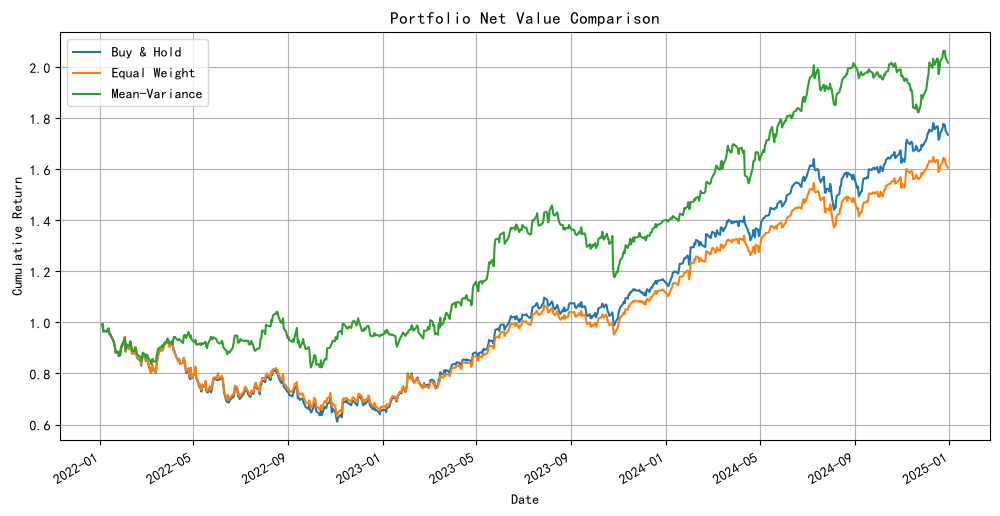

In [72]:
plt.figure(figsize=(12, 6))
(1 + bh_ret).cumprod().plot(label='Buy & Hold')
(1 + eq_ret).cumprod().plot(label='Equal Weight')
(1 + mv_ret).cumprod().plot(label='Mean-Variance')
plt.title('Portfolio Net Value Comparison')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

Buy & Hold
                 
count  751.000000
mean    -0.112958
std      0.116933
min     -0.385440
25%     -0.218102
50%     -0.058873
75%     -0.010413
max      0.000000 

Equal Weight
                 
count  751.000000
mean    -0.111571
std      0.112200
min     -0.363986
25%     -0.214567
50%     -0.064468
75%     -0.010543
max      0.000000 

Mean-Variance
                 
count  751.000000
mean    -0.053090
std      0.045813
min     -0.210068
25%     -0.082653
50%     -0.046778
75%     -0.012608
max      0.000000 



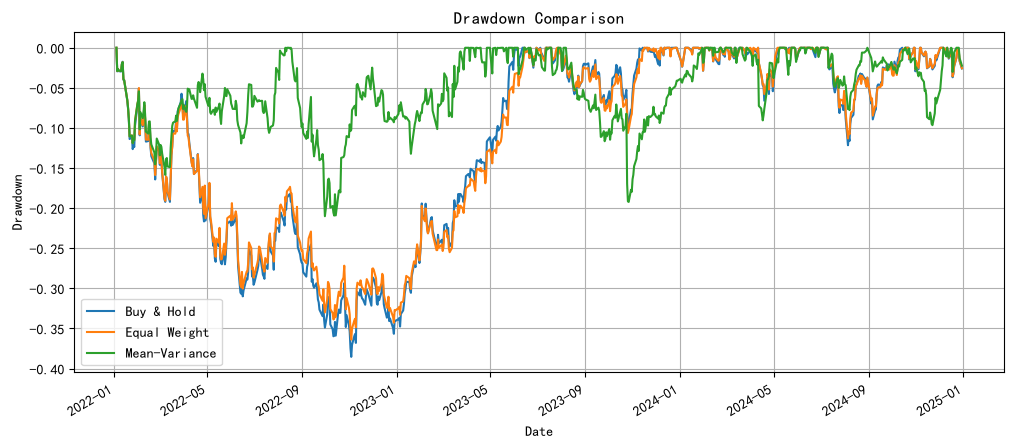

In [73]:
plt.figure(figsize=(12, 5))
plot_drawdown(bh_ret, 'Buy & Hold')
plot_drawdown(eq_ret, 'Equal Weight')
plot_drawdown(mv_ret, 'Mean-Variance')
plt.title('Drawdown Comparison')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()